In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = pd.read_csv('../data/sample_car_contracts.csv')

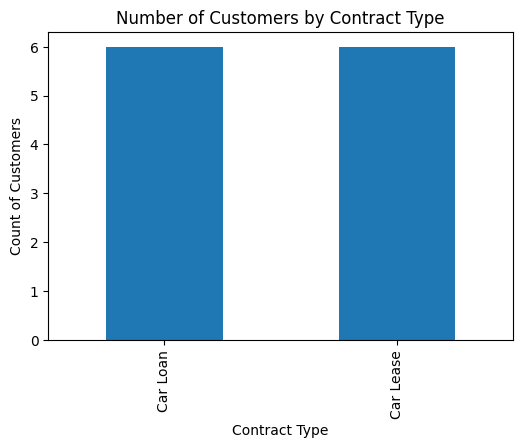

In [4]:
#Count of Customers by Contract Type

contract_counts = df['contract_type'].value_counts()

plt.figure(figsize=(6,4))
contract_counts.plot(kind='bar')
plt.title("Number of Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count of Customers")
plt.show()


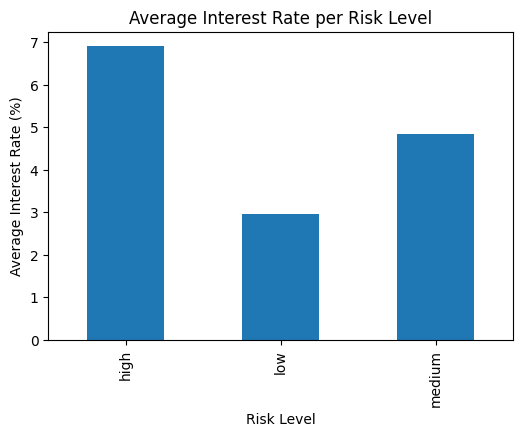

In [5]:
#Average Interest Rate by Risk Level

avg_interest = df.groupby('risk_flag')['interest_rate'].mean()

plt.figure(figsize=(6,4))
avg_interest.plot(kind='bar')
plt.title("Average Interest Rate per Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Interest Rate (%)")
plt.show()


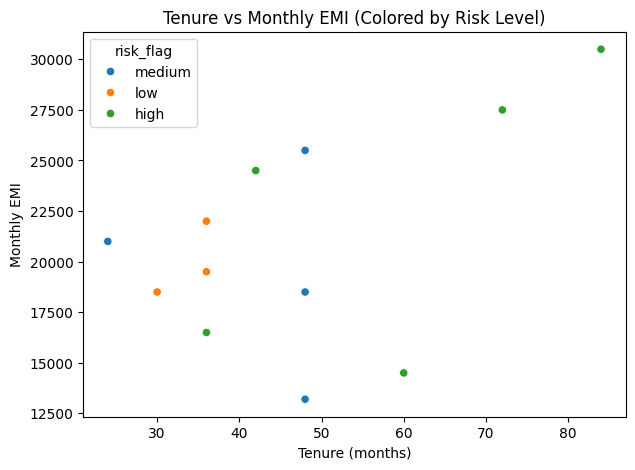

In [6]:
#Tenure vs Monthly EMI colored by Risk Level

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='tenure_months',
    y='monthly_emi',
    hue='risk_flag'
)

plt.title("Tenure vs Monthly EMI (Colored by Risk Level)")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly EMI")
plt.show()


In [7]:
df["contract_length"]=df["clause_summary"].apply(lambda x: len(str(x).split()))
df[["clause_summary","contract_length"]]

,clause_summary,contract_length
0,Prepayment allowed only after 24 months with 5...,9
1,Lessee must pay for all maintenance and insurance,8
2,Late payment fee of 3% per month on outstandin...,10
3,"Excess mileage charge of ₹12 per km over 15,00...",12
4,Floating interest rate linked to lender's inte...,8
5,Early termination fee equal to 6 months of EMI,9
6,No foreclosure charges after 12 months,6
7,Battery warranty covered only for 24 months or...,10
8,Mandatory bundled insurance from lender at non...,8
9,"Security deposit of 3 EMIs, refundable at end ...",14


In [8]:
keywords=["fee","penalty","late","extra"]
df["hidden_charges_flag"]=df["clause_summary"].apply(
    lambda x: [word for word in keywords if word in x]
)
df[["clause_summary", "hidden_charges_flag"]]

,clause_summary,hidden_charges_flag
0,Prepayment allowed only after 24 months with 5...,[penalty]
1,Lessee must pay for all maintenance and insurance,[]
2,Late payment fee of 3% per month on outstandin...,[fee]
3,"Excess mileage charge of ₹12 per km over 15,00...",[]
4,Floating interest rate linked to lender's inte...,[]
5,Early termination fee equal to 6 months of EMI,[fee]
6,No foreclosure charges after 12 months,[]
7,Battery warranty covered only for 24 months or...,[]
8,Mandatory bundled insurance from lender at non...,[]
9,"Security deposit of 3 EMIs, refundable at end ...",[]


In [9]:
from collections import Counter
high=df[df["risk_flag"]=="high"]
text=" ".join(high["clause_summary"])
words=text.split()
stop = ["the","a","and","in","for","to","of","is","on","with","per","only"]
cleaned_words = []
for w in words:
    w = w.strip(",.!")     
    if w not in stop:  
        cleaned_words.append(w)
Counter(cleaned_words).most_common(10)

[('fee', 2),
 ('Late', 1),
 ('payment', 1),
 ('3%', 1),
 ('month', 1),
 ('outstanding', 1),
 ('amount', 1),
 ('Floating', 1),
 ('interest', 1),
 ('rate', 1)]

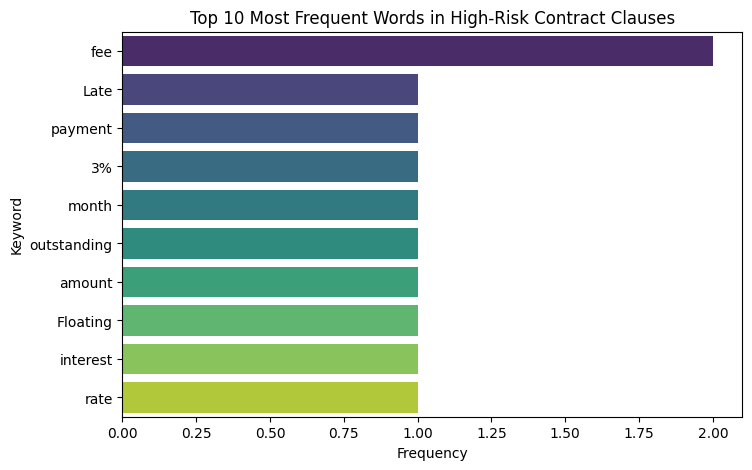

In [10]:
top_words = Counter(cleaned_words).most_common(10)
top_df = pd.DataFrame(top_words, columns=["word", "count"])
plt.figure(figsize=(8,5))
sns.barplot(data=top_df, x="count", y="word", hue="word", palette="viridis", legend=False)
plt.title("Top 10 Most Frequent Words in High-Risk Contract Clauses")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()